# Use case 4: DEODE on-demand runs announce a region, subscribers in that region react, data comes via Polytope

**Use case.** DEODE (Destination Earth On-Demand Extremes Digital Twin, DE_330) runs limited-area,
high-resolution forecasts over a region chosen at request time. Today only NMHSs can trigger such
runs. Whoever triggers one should also be able to **announce it through Aviso for that specific
region**, so that only subscribers whose area of interest overlaps the domain are woken up, and so
that they can pull the fields **for that region via Polytope**.

This notebook plays both roles on the Aviso 2 playground:

1. the **producer** (the NMHS / DEODE workflow) publishes a spatial notification whose identifier
   carries the run's domain outline;
2. **subscribers** filter geographically (a polygon that must *intersect*, or a point that must be
   *contained*) and only those in the region are notified;
3. a subscriber turns the notification into a **regional Polytope request** with earthkit-data and
   plots the region with earthkit-plots.

| Setting | Value |
| --- | --- |
| Aviso server | `https://aviso-playground.ecmwf.int` (Aviso 2, shared sandbox) |
| Spatial streams | `de-scm-data-points` (publisher: `point_cloud`, subscriber: `polygon`) and `extreme_event` (`polygon` string, `point`, `severity` constraints) |
| Aviso auth | ECMWF token (`AVISO_TOKEN` or `~/.config/aviso/config.yaml`, from <https://api.ecmwf.int/v1/key/>) |
| Data | Polytope `polytope.lumi.apps.dte.destination-earth.eu`, dataset `extremes-dt` (DESP token in `~/.polytopeapirc`) |
| Client | `pip install pyaviso earthkit-data earthkit-plots pyyaml pandas` |

> **DEODE output is on Polytope.** On-demand runs are served from the collection
> `dataset: on-demand-extremes-dt` (`class: d1`, `stream: oper`, `type: fc`, `expver: 0099`) and
> every run is identified by a **`georef`** key that names its limited-area domain (for example
> `georef: gcgkrb`, `date: 20250926`, `time: 0000`, the run with feature extraction enabled). The
> available key-values are browsable in the
> [DestinE STAC catalogue](https://catalogue.lumi.apps.dte.destination-earth.eu/?class=d1&dataset=on-demand-extremes-dt&stream=oper&expver=0099&type=fc&date=2025-09-26&time=0000&georef=gcgkrb).
> The Aviso announcement of a run therefore has to carry **`georef` plus `date`, `time` and
> `expver`**: with those four values a subscriber can build the Polytope request directly.

## 1. Setup and authentication

The playground accepts any valid ECMWF API token for read and write. The token is taken from
`AVISO_TOKEN` or from the aviso CLI config file and never printed.

In [1]:
# %pip install -q pyaviso earthkit-data earthkit-plots pyyaml pandas

import json
import os
import pathlib
import queue
import threading
import time
from datetime import datetime, timedelta, timezone

import numpy as np
import pandas as pd
import pyaviso
import earthkit.data as ekd
import earthkit.plots as ekp
from IPython.display import display

BASE_URL = os.environ.get("AVISO_BASE_URL", "https://aviso-playground.ecmwf.int").rstrip("/")
POINTS_EVENT = "de-scm-data-points"
EXTREME_EVENT = "extreme_event"
POLYTOPE_ADDRESS = "polytope.lumi.apps.dte.destination-earth.eu"
OUT_DIR = pathlib.Path("output") / "uc04-deode"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CLI_CONFIG = pathlib.Path.home() / ".config" / "aviso" / "config.yaml"


def resolve_token():
    if os.environ.get("AVISO_TOKEN"):
        return os.environ["AVISO_TOKEN"]
    if CLI_CONFIG.exists():
        import yaml
        cfg = yaml.safe_load(CLI_CONFIG.read_text(encoding="utf-8")) or {}
        tok = (cfg.get("auth") or {}).get("bearer_token")
        if tok:
            return tok
    raise RuntimeError("no aviso token: set AVISO_TOKEN or auth.bearer_token in ~/.config/aviso/config.yaml")


TOKEN = resolve_token()
client = pyaviso.AvisoClient(base_url=BASE_URL, auth=pyaviso.Bearer(TOKEN))
print("pyaviso", pyaviso.__version__, "| connected to", client.base_url)


def open_stream(client, event_type, *, filter, start=None, mode=None):
    # pyaviso 2.1.0 names the cursor `start_from=`; newer builds `from_=`.
    kwargs = {"filter": filter}
    if mode is not None:
        kwargs["mode"] = mode
    if start is None:
        return client.listen(event_type, **kwargs)
    try:
        return client.listen(event_type, start_from=start, **kwargs)
    except TypeError:
        return client.listen(event_type, from_=start, **kwargs)


def replay(client, event_type, *, filter, start=1):
    with open_stream(client, event_type, filter=filter, start=start, mode="replay_only") as s:
        return list(s)

pyaviso 2.1.0 | connected to https://aviso-playground.ecmwf.int/


## 2. The two spatial streams

Both streams filter **server-side by geometry**; the geometry is not part of the stream topic, so
one publish reaches exactly the subscribers whose geometry matches.

| Stream | Publisher sends | Subscriber sends | Match rule |
| --- | --- | --- | --- |
| `de-scm-data-points` | `point_cloud`: `[[lat, lon], ...]` (≤ 10 000 points) | `polygon`: closed list of `[lat, lon]` | delivered if any point of the cloud lies inside the polygon (intersection) |
| `extreme_event` | `polygon`: string `"(lat,lon,lat,lon,...)"`, closed ring | `polygon` string (intersects) **or** `point` `"lat,lon"` (contained) | plus exact/constraint match on `region`, `run_time`, `severity` |

`extreme_event` also shows **value constraints** on scalar identifiers (`{"gte": 5}`), which is how
a subscriber says "only warn me for severity 5 and above".

In [2]:
rows = []
for ev in (POINTS_EVENT, EXTREME_EVENT):
    sch = client.schema_for(ev).schema
    for key, spec in sch["identifier"].items():
        rows.append({"stream": ev, "identifier": key, "type": spec.get("type"), "required": spec.get("required", False),
                     "notes": spec.get("description") or spec.get("values") or spec.get("range") or spec.get("max_points") or ""})
    rows.append({"stream": ev, "identifier": "(payload)", "type": "JSON", "required": sch["payload"].get("required"), "notes": ""})
pd.DataFrame(rows).set_index(["stream", "identifier"])

type  required  \
stream             identifier                                 
de-scm-data-points date               DateHandler     False   
                   experiment       StringHandler      True   
                   point_cloud  PointCloudHandler      True   
                   time               TimeHandler     False   
                   (payload)                 JSON     False   
extreme_event      anomaly           FloatHandler     False   
                   polygon         PolygonHandler      True   
                   region             EnumHandler      True   
                   run_time           TimeHandler      True   
                   severity            IntHandler      True   
                   (payload)                 JSON     False   

                                                                            notes  
stream             identifier                                                      
de-scm-data-points date                                                            
                   experiment                                                      
                   point_cloud  Publishers provide point_cloud as [[latitude, ...  
                   time                                                            
                   (payload)                                                       
extreme_event      anomaly                                           [0.0, 100.0]  
                   polygon                                                         
                   region                                Geographic region label.  
                   run_time                                                        
                   severity                           Severity level from 1 to 7.  
                   (payload)

## 3. The on-demand domain

A DEODE request defines a limited-area domain, identified afterwards by its `georef`. We use the
run `gcgkrb` of 2025-09-26 00 UTC over Portugal and describe its (approximate) box two ways: as a **point cloud** (outline sampled along the edges plus a coarse interior grid, the shape
`de-scm-data-points` expects) and as a **closed polygon** (the shape `extreme_event` and all
subscribers use). Change `GEOREF`/`DOMAIN` for another run.

In [3]:
# north, south, west, east  (degrees)
GEOREF = "gcgkrb"                       # on-demand run id; its domain covers Portugal (Lisbon is inside)
RUN_DATE, RUN_TIME, EXPVER = "20250926", "0000", "0099"
DOMAIN = {"name": GEOREF, "N": 43.0, "S": 36.0, "W": -10.5, "E": -5.5}   # approximate outline; exact extent: STAC catalogue


def domain_polygon(d):
    # closed ring of [lat, lon], counter-clockwise
    return [[d["S"], d["W"]], [d["S"], d["E"]], [d["N"], d["E"]], [d["N"], d["W"]], [d["S"], d["W"]]]


def domain_point_cloud(d, edge_step=0.5, grid_step=2.0):
    pts = set()
    for lon in np.arange(d["W"], d["E"] + 1e-9, edge_step):
        pts.add((d["S"], round(float(lon), 3))); pts.add((d["N"], round(float(lon), 3)))
    for lat in np.arange(d["S"], d["N"] + 1e-9, edge_step):
        pts.add((round(float(lat), 3), d["W"])); pts.add((round(float(lat), 3), d["E"]))
    for lat in np.arange(d["S"], d["N"] + 1e-9, grid_step):
        for lon in np.arange(d["W"], d["E"] + 1e-9, grid_step):
            pts.add((round(float(lat), 3), round(float(lon), 3)))
    return [[lat, lon] for lat, lon in sorted(pts)]


def polygon_string(ring):
    # extreme_event wants "(lat,lon,lat,lon,...)"
    return "(" + ",".join(f"{lat},{lon}" for lat, lon in ring) + ")"


POLY = domain_polygon(DOMAIN)
CLOUD = domain_point_cloud(DOMAIN)
print(f"{DOMAIN['name']}: polygon {POLY}")
print(f"point cloud: {len(CLOUD)} points, first {CLOUD[:3]} ...")
print("extreme_event polygon string:", polygon_string(POLY))

gcgkrb: polygon [[36.0, -10.5], [36.0, -5.5], [43.0, -5.5], [43.0, -10.5], [36.0, -10.5]]
point cloud: 54 points, first [[36.0, -10.5], [36.0, -10.0], [36.0, -9.5]] ...
extreme_event polygon string: (36.0,-10.5,36.0,-5.5,43.0,-5.5,43.0,-10.5,36.0,-10.5)


## 4. Producer: announce the run on `de-scm-data-points`

The publisher supplies every identifier of the schema (`experiment`, `date`, `time`,
`point_cloud`) plus a payload. The playground stream has no `georef` key, so the mapping is:

| Polytope key | Aviso identifier | Note |
| --- | --- | --- |
| `georef` | `experiment` | ≤ 10 characters, fits a georef; a production stream would name the key `georef` |
| `date`, `time` | `date`, `time` | base time of the run |
| domain outline | `point_cloud` | what the spatial filter matches against |
| `expver`, `dataset`, `class`, address | payload | everything else the subscriber needs |

`PUBLISH` is the opt-in switch; the playground is a shared sandbox and the payload is marked as a
notebook test.

In [4]:
PUBLISH = True
EXPERIMENT = GEOREF                      # georef travels in the `experiment` identifier on this stream

def deode_announcement():
    return dict(
        event_type=POINTS_EVENT,
        identifier={"experiment": EXPERIMENT, "date": RUN_DATE, "time": RUN_TIME, "point_cloud": CLOUD},
        payload={"note": "deode-uc4-notebook-test", "georef": GEOREF, "region": DOMAIN["name"],
                 "bbox": {k: DOMAIN[k] for k in ("N", "S", "W", "E")},
                 "polytope": {"address": POLYTOPE_ADDRESS, "dataset": "on-demand-extremes-dt", "class": "d1",
                              "stream": "oper", "type": "fc", "expver": EXPVER},
                 "published_by": "04-deode-regional-notifications-polytope.ipynb"},
    )

if PUBLISH:
    resp = client.notify(**deode_announcement())
    print("published:", resp.status, "request_id", resp.request_id, "at", resp.processed_at)
else:
    print("PUBLISH = False, nothing sent")

published: success request_id f1776d86-dc7f-41ee-9bab-6c90a232aa86 at 2026-09-24T15:45:35Z


## 5. Subscribers: only the overlapping region is told

Subscribers replay the stream from the beginning with their own area of interest. Lisbon's box
overlaps the run domain and receives the announcement; Munich's does not and stays silent.
The subscriber polygon is a **closed** `[lat, lon]` ring and satisfies the required `point_cloud`
field on the subscriber side (subscribers must not send `point_cloud`).

In [5]:
SUBSCRIBERS = {
    "Lisbon box (overlaps)":  [[37.5, -10.0], [37.5, -8.0], [39.5, -8.0], [39.5, -10.0], [37.5, -10.0]],
    "Munich box (disjoint)":  [[47.0, 10.5], [47.0, 12.5], [49.5, 12.5], [49.5, 10.5], [47.0, 10.5]],
    "Whole of Europe":        [[30.0, -30.0], [30.0, 45.0], [75.0, 45.0], [75.0, -30.0], [30.0, -30.0]],
}

for label, ring in SUBSCRIBERS.items():
    got = replay(client, POINTS_EVENT, filter={"experiment": EXPERIMENT, "polygon": ring}, start=1)
    print(f"{label:<24} -> {len(got)} notification(s)"
          + (f"; latest seq={got[-1].sequence} date={got[-1].identifier['date']} payload.region={got[-1].payload.get('region')}" if got else ""))

Lisbon box (overlaps)    -> 1 notification(s); latest seq=20 date=20250926 payload.region=gcgkrb
Munich box (disjoint)    -> 0 notification(s)
Whole of Europe          -> 1 notification(s); latest seq=20 date=20250926 payload.region=gcgkrb


### Live: subscribe first, then the run is announced

A time-bounded live watch (a worker thread blocks on the stream and queues notifications, the cell
enforces the deadline). The publish is fired from another thread about 1.5 s after the watch
opens, which mimics the producer and the subscriber being different processes.

In [6]:
def listen_for(client, event_type, *, filter, seconds=20, max_items=None, start=None, on_open=None):
    stream = open_stream(client, event_type, filter=filter, start=start)
    q = queue.Queue()

    def pump():
        try:
            for n in stream:
                q.put(n)
        except Exception as exc:
            q.put(exc)
        finally:
            q.put(None)

    threading.Thread(target=pump, daemon=True).start()
    if on_open:
        threading.Timer(1.5, on_open).start()      # give the SSE handshake time to complete
    got, t0, deadline = [], time.monotonic(), time.monotonic() + seconds
    while time.monotonic() < deadline:
        try:
            item = q.get(timeout=min(1.0, max(deadline - time.monotonic(), 0.01)))
        except queue.Empty:
            continue
        if item is None:
            break
        if isinstance(item, Exception):
            print("stream error:", type(item).__name__, item)
            break
        got.append(item)
        print(f"[{time.monotonic() - t0:5.1f}s] seq={item.sequence} experiment={item.identifier.get('experiment')} "
              f"date={item.identifier.get('date')} payload={item.payload}")
        if max_items and len(got) >= max_items:
            break
    stream.close()
    print(f"watch closed after {time.monotonic() - t0:.1f}s with {len(got)} notification(s)")
    return got


def publish_announcement():
    if PUBLISH:
        r = client.notify(**deode_announcement())
        print(f"   (producer published: {r.status})")


live_lisbon = listen_for(client, POINTS_EVENT, filter={"experiment": EXPERIMENT, "polygon": SUBSCRIBERS["Lisbon box (overlaps)"]},
                         seconds=15, max_items=1, on_open=publish_announcement)

   (producer published: success)[  1.5s] seq=21 experiment=gcgkrb date=20250926 payload={'bbox': {'E': -5.5, 'N': 43.0, 'S': 36.0, 'W': -10.5}, 'georef': 'gcgkrb', 'note': 'deode-uc4-notebook-test', 'polytope': {'address': 'polytope.lumi.apps.dte.destination-earth.eu', 'class': 'd1', 'dataset': 'on-demand-extremes-dt', 'expver': '0099', 'stream': 'oper', 'type': 'fc'}, 'published_by': '04-deode-regional-notifications-polytope.ipynb', 'region': 'gcgkrb'}

watch closed after 1.6s with 1 notification(s)


In [7]:
# The disjoint subscriber sees nothing even though the same announcement is published again.
live_munich = listen_for(client, POINTS_EVENT, filter={"experiment": EXPERIMENT, "polygon": SUBSCRIBERS["Munich box (disjoint)"]},
                         seconds=8, max_items=1, on_open=publish_announcement)

   (producer published: success)


watch closed after 8.0s with 0 notification(s)


## 6. Alternative stream: `extreme_event` with a severity threshold

If the on-demand run is triggered *because* of an expected extreme, the `extreme_event` stream fits:
the polygon is a string, `severity` is an integer 1-7 and subscribers can use constraints. A
subscriber can also give a single **point** (its station or city) instead of a polygon and gets
events whose polygon **contains** it.

In [8]:
PUBLISH_EXTREME = True
EXTREME_RUN_TIME = "0000"

if PUBLISH_EXTREME:
    r = client.notify(
        event_type=EXTREME_EVENT,
        identifier={"region": "south", "run_time": EXTREME_RUN_TIME, "severity": "5", "anomaly": "37.5",
                    "polygon": polygon_string(POLY)},
        payload={"note": "deode-uc4-notebook-test", "region": DOMAIN["name"], "trigger": "on-demand run requested"},
    )
    print("published extreme_event:", r.status)

cases = {
    "Lisbon point, severity >= 4 (inside)":     {"region": "south", "run_time": EXTREME_RUN_TIME, "severity": {"gte": 4}, "point": "38.72,-9.14"},
    "Lisbon point, severity >= 6 (too low)":    {"region": "south", "run_time": EXTREME_RUN_TIME, "severity": {"gte": 6}, "point": "38.72,-9.14"},
    "Innsbruck point (outside)":                {"region": "south", "run_time": EXTREME_RUN_TIME, "severity": {"gte": 1}, "point": "47.27,11.39"},
    "Lisbon box polygon (intersects)":          {"region": "south", "run_time": EXTREME_RUN_TIME, "severity": {"gte": 1},
                                                 "polygon": polygon_string(SUBSCRIBERS["Lisbon box (overlaps)"])},
}
for label, f in cases.items():
    got = [n for n in replay(client, EXTREME_EVENT, filter=f, start=1) if (n.payload or {}).get("note") == "deode-uc4-notebook-test"]
    print(f"{label:<44} -> {len(got)} matching notebook event(s)")

published extreme_event: success
Lisbon point, severity >= 4 (inside)         -> 1 matching notebook event(s)
Lisbon point, severity >= 6 (too low)        -> 0 matching notebook event(s)
Innsbruck point (outside)                    -> 0 matching notebook event(s)
Lisbon box polygon (intersects)              -> 1 matching notebook event(s)


## 7. Subscriber side: from the notification to the on-demand Polytope request

The identifier (`experiment` = georef, `date`, `time`) and the payload (`expver`, `dataset`, address)
are everything Polytope needs. `on_demand_request()` does the mapping and optionally adds a
**feature** (timeseries, polygon, vertical profile, trajectory) so the subscriber pulls only what it
needs from the run. One real retrieval follows: the 2 m temperature time series at Lisbon, steps
0-10, from run `gcgkrb`.

earthkit-data 1.x returns a `GribData` object; call `.to_fieldlist()` before indexing fields.
Polytope serves roughly the last two weeks of Extremes-DT dates, so this request uses a recent base
date; the on-demand run above is older and is served from its own collection.

In [9]:
def on_demand_request(n, *, param="167", levtype="sfc", step=None, feature=None, levelist=None):
    ident, payload = n.identifier, (n.payload or {})
    pt = payload.get("polytope", {})
    req = {"class": pt.get("class", "d1"), "dataset": pt.get("dataset", "on-demand-extremes-dt"),
           "stream": pt.get("stream", "oper"), "type": pt.get("type", "fc"), "expver": pt.get("expver", "0099"),
           "georef": payload.get("georef") or ident.get("georef") or ident["experiment"],
           "date": str(ident["date"]), "time": str(ident["time"]), "levtype": levtype, "param": str(param)}
    if step is not None:
        req["step"] = str(step)
    if levelist is not None:
        req["levelist"] = levelist
    if feature is not None:
        req["feature"] = feature
    return req


announcement = live_lisbon[0] if live_lisbon else pyaviso.Notification(POINTS_EVENT, 0, deode_announcement()["identifier"], deode_announcement()["payload"])
LISBON = (38.72, -9.14)

examples = {
    "time series at Lisbon":      on_demand_request(announcement, feature={"type": "timeseries", "points": [list(LISBON)], "axes": "step", "range": {"start": 0, "end": 10}}),
    "polygon mean, steps 1-9":    on_demand_request(announcement, step="1/to/9", feature={"type": "polygon", "shape": [[p[0], p[1]] for p in SUBSCRIBERS["Lisbon box (overlaps)"]]}),
    "vertical profile (q, pl)":   on_demand_request(announcement, param="133", levtype="pl", step="5", levelist="1/to/1000", feature={"type": "verticalprofile", "points": [list(LISBON)]}),
    "full field, step 1":         on_demand_request(announcement, step="1"),
}
for label, r in examples.items():
    print(f"{label:<28} {json.dumps(r)}")

time series at Lisbon        {"class": "d1", "dataset": "on-demand-extremes-dt", "stream": "oper", "type": "fc", "expver": "0099", "georef": "gcgkrb", "date": "20250926", "time": "0000", "levtype": "sfc", "param": "167", "feature": {"type": "timeseries", "points": [[38.72, -9.14]], "axes": "step", "range": {"start": 0, "end": 10}}}
polygon mean, steps 1-9      {"class": "d1", "dataset": "on-demand-extremes-dt", "stream": "oper", "type": "fc", "expver": "0099", "georef": "gcgkrb", "date": "20250926", "time": "0000", "levtype": "sfc", "param": "167", "step": "1/to/9", "feature": {"type": "polygon", "shape": [[37.5, -10.0], [37.5, -8.0], [39.5, -8.0], [39.5, -10.0], [37.5, -10.0]]}}
vertical profile (q, pl)     {"class": "d1", "dataset": "on-demand-extremes-dt", "stream": "oper", "type": "fc", "expver": "0099", "georef": "gcgkrb", "date": "20250926", "time": "0000", "levtype": "pl", "param": "133", "step": "5", "levelist": "1/to/1000", "feature": {"type": "verticalprofile", "points": [[38

2026-09-24 17:45:46 - INFO - Key read from /Users/mauf/.polytopeapirc


2026-09-24 17:45:46 - INFO - Sending request...
{'request': 'class: d1\n'
            'dataset: on-demand-extremes-dt\n'
            "date: '20250926'\n"
            'expver: 0099\n'
            'feature:\n'
            '  axes: step\n'
            '  points:\n'
            '  - - 38.72\n'
            '    - -9.14\n'
            '  range:\n'
            '    end: 10\n'
            '    start: 0\n'
            '  type: timeseries\n'
            'georef: gcgkrb\n'
            'levtype: sfc\n'
            "param: '167'\n"
            'stream: oper\n'
            "time: '0000'\n"
            'type: fc\n',
 'verb': 'retrieve'}


2026-09-24 17:45:46 - INFO - Polytope user key found in session cache for user mauf


2026-09-24 17:45:47 - INFO - Request accepted. Please poll ./01ejwrk9838302p00bscwr5t2j for status


2026-09-24 17:45:47 - INFO - Polytope user key found in session cache for user mauf


2026-09-24 17:45:47 - INFO - Checking request status (01ejwrk9838302p00bscwr5t2j)...


2026-09-24 17:45:53 - INFO - The current status of the request is 'processed'


01ejwrk9838302p00bscwr5t2j.covjson:   0%|          | 0.00/2.16k [00:00<?, ?B/s]

on-demand retrieval OK in 15.1s -> on-demand_gcgkrb_20250926_2t_lisbon_timeseries.nc


<xarray.Dataset> Size: 288B
Dimensions:    (latitude: 1, longitude: 1, levelist: 1, number: 1, datetime: 1,
                t: 11)
Coordinates:
  * latitude   (latitude) float64 8B 58.08
  * longitude  (longitude) float64 8B 0.0005
  * levelist   (levelist) int64 8B 0
  * number     (number) int64 8B 0
  * datetime   (datetime) <U20 80B '2025-09-26T00:00:00Z'
  * t          (t) datetime64[ns] 88B 2025-09-26 ... 2025-09-26T10:00:00
Data variables:
    2t         (latitude, longitude, levelist, number, datetime, t) float64 88B ...
Attributes:
    class:          d1
    dataset:        on-demand-extremes-dt
    Forecast date:  2025-09-26T00:00:00Z
    expver:         0099
    georef:         gcgkrb
    levtype:        sfc
    stream:         oper
    type:           fc
    number:         0
    levelist:       0

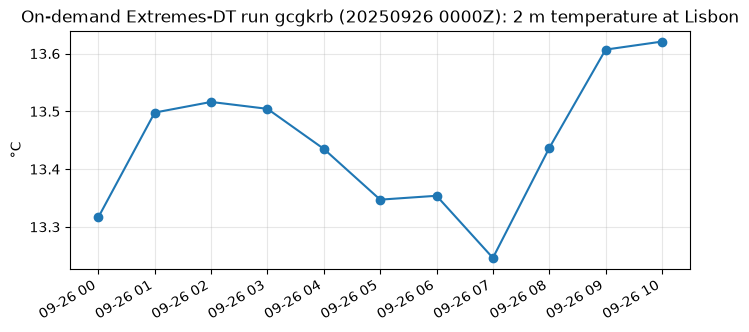

In [10]:
LIVE_REQUEST = os.getenv("LIVE_REQUEST", "true").lower() == "true"   # polytope-examples convention: False -> reuse a cached file
ts_file = OUT_DIR / f"on-demand_{GEOREF}_{RUN_DATE}_2t_lisbon_timeseries.nc"

t0 = time.monotonic()
if LIVE_REQUEST or not ts_file.exists():
    ts_request = examples["time series at Lisbon"]
    ts_data = ekd.from_source("polytope", "destination-earth", ts_request, address=POLYTOPE_ADDRESS, stream=False)
    ts = ts_data.to_xarray()                       # CoverageJSON -> xarray (to_pandas is not implemented for covjson)
    ts.to_netcdf(ts_file)
    print(f"on-demand retrieval OK in {time.monotonic() - t0:.1f}s -> {ts_file.name}")
else:
    import xarray as xr
    ts = xr.open_dataset(ts_file)
    print("using cached", ts_file.name)
display(ts)

import matplotlib.pyplot as plt
da = ts["2t"].squeeze()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(da["t"].values, da.values - 273.15, marker="o")
ax.set_title(f"On-demand Extremes-DT run {GEOREF} ({RUN_DATE} {RUN_TIME}Z): 2 m temperature at Lisbon")
ax.set_ylabel("°C"); ax.grid(alpha=0.3); fig.autofmt_xdate()
fig.savefig(OUT_DIR / f"on-demand_{GEOREF}_{RUN_DATE}_2t_lisbon.png", dpi=120, bbox_inches="tight")
plt.show()

### Regional context from the global Extremes-DT

Subscribers often want the global model's view of the same box for comparison. Polytope accepts a
MARS-style `area: [N, W, S, E]` on the `extremes-dt` collection and returns only the points inside
(for this box a few tens of kB instead of the 50 MB global field). This is the second and last
Polytope request of the notebook.

2026-09-24 17:46:01 - INFO - Key read from /Users/mauf/.polytopeapirc


2026-09-24 17:46:01 - INFO - Sending request...
{'request': 'area:\n'
            '- 43.0\n'
            '- -10.5\n'
            '- 36.0\n'
            '- -5.5\n'
            'class: d1\n'
            'dataset: extremes-dt\n'
            "date: '20260922'\n"
            "expver: '0001'\n"
            'levtype: sfc\n'
            "param: '167'\n"
            "step: '0'\n"
            'stream: oper\n'
            "time: '0000'\n"
            'type: fc\n',
 'verb': 'retrieve'}


2026-09-24 17:46:01 - INFO - Polytope user key found in session cache for user mauf


Polytope request: {"class": "d1", "dataset": "extremes-dt", "expver": "0001", "stream": "oper", "type": "fc", "levtype": "sfc", "date": "20260922", "time": "0000", "step": "0", "param": "167", "area": [43.0, -10.5, 36.0, -5.5]}


2026-09-24 17:46:16 - INFO - Request accepted. Please poll ./01ejwrk9838303j00bxtczmqf5 for status


...

2026-09-24 17:46:26 - INFO - The current status of the request is 'processed'


01ejwrk9838303j00bxtczmqf5.grib:   0%|          | 0.00/41.5k [00:00<?, ?B/s]

retrieved 1 field(s), 15932 grid points in the box, in 25.6s


,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,2t,2026-09-22,2026-09-22,0 days,2,height_above_ground_level,None,reduced_gg


ECCODES ERROR   :  grid_spec: Buffer too small for gridSpec. It is 10914 bytes long (len=1025)


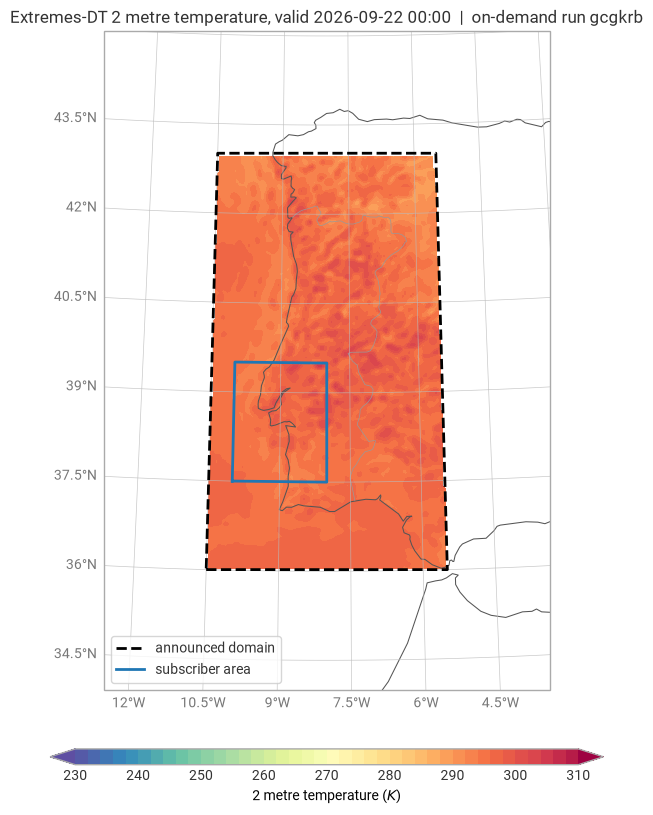

In [11]:
import cartopy.crs as ccrs

def bbox_from_notification(n):
    # Prefer the payload bbox; otherwise derive it from the point cloud / polygon in the identifier.
    payload = n.payload or {}
    if isinstance(payload, dict) and "bbox" in payload:
        b = payload["bbox"]
        return b["N"], b["W"], b["S"], b["E"]
    pts = n.identifier.get("point_cloud") or n.identifier.get("polygon") or []
    lats = [p[0] for p in pts]; lons = [p[1] for p in pts]
    return max(lats), min(lons), min(lats), max(lons)


def regional_request(n, *, param="167", step="0", date=None, time_="0000"):
    N, W, S, E = bbox_from_notification(n)
    date = date or (datetime.now(timezone.utc) - timedelta(days=2)).strftime("%Y%m%d")
    return {"class": "d1", "dataset": "extremes-dt", "expver": "0001", "stream": "oper", "type": "fc",
            "levtype": "sfc", "date": date, "time": time_, "step": str(step), "param": param,
            "area": [N, W, S, E]}


# Use the announcement that the Munich subscriber received (or rebuild it if the live cell got nothing).
request = regional_request(announcement)
print("Polytope request:", json.dumps(request))

t0 = time.monotonic()
data = ekd.from_source("polytope", "destination-earth", request, address=POLYTOPE_ADDRESS, stream=False)
fields = data.to_fieldlist()
field = fields[0]
print(f"retrieved {len(fields)} field(s), {field.shape[0]} grid points in the box, in {time.monotonic() - t0:.1f}s")
fields.to_target("file", str(OUT_DIR / "region_{date}_{time}_step{step}_{param}.grib".format(**request)))
display(fields.ls())

N, W, S, E = request["area"]
pad = 2.0
chart = ekp.Map(domain=[W - pad, E + pad, S - pad, N + pad])      # [west, east, south, north]
chart.quickplot(field)
chart.coastlines(); chart.borders(); chart.gridlines(); chart.legend()
chart.title("Extremes-DT {variable_name}, valid {valid_time:%Y-%m-%d %H:%M}  |  on-demand run " + GEOREF)
ring = domain_polygon({"N": N, "S": S, "W": W, "E": E})
chart.ax.plot([p[1] for p in ring], [p[0] for p in ring], transform=ccrs.PlateCarree(), color="k", lw=2, ls="--", label="announced domain")
sub = SUBSCRIBERS["Lisbon box (overlaps)"]
chart.ax.plot([p[1] for p in sub], [p[0] for p in sub], transform=ccrs.PlateCarree(), color="tab:blue", lw=2, label="subscriber area")
chart.ax.legend(loc="lower left")
chart.save(OUT_DIR / f"region_{DOMAIN['name']}_{request['date']}.png")
chart.show()

## 8. Running this as a service

The subscriber side is a one-file `aviso listen` job. Save as `deode-region.yaml` and run
`AVISO_BASE_URL=https://aviso-playground.ecmwf.int aviso listen deode-region.yaml`:

```yaml
listeners:
  - name: deode-munich
    event: de-scm-data-points
    identifiers:
      experiment: "*"
      polygon: [[47.0, 10.5], [47.0, 12.5], [49.5, 12.5], [49.5, 10.5], [47.0, 10.5]]
    triggers:
      - type: echo
      - type: command
        command: >-
          python fetch_region.py --bbox '{{ notification.payload.bbox }}'
          --date {{ notification.identifier.date }} --time {{ notification.identifier.time }}
        timeout: 900
```

Practicalities from the Polytope examples repository:

* **`LIVE_REQUEST` pattern.** The polytope-examples notebooks read `LIVE_REQUEST` from the
  environment and fall back to a cached file when it is `false`; the time-series cell above does the
  same, so a re-run without network reuses `output/uc04-deode/*.nc`.
* **Quota.** Polytope for DestinE allows up to **50 requests per second** and at most **5 concurrent
  downloads** per user; a listener that fans out one request per notification should queue them.
* **Two data bridges.** The same collections exist on LUMI (`polytope.lumi.apps.dte.destination-earth.eu`)
  and MareNostrum 5 (`polytope.mn5.apps.dte.destination-earth.eu`); only the `address` argument
  changes. Which bridge holds a given on-demand run should be part of the notification payload.
* **Projection.** On-demand runs are limited-area `lambert_lam` grids; CoverageJSON coordinates of
  feature results are in that projection's units, so keep the request point for labelling. Full
  fields plot with `earthkit.plots.Map().grid_cells(data)`.
* **Retention.** The 2025-09-26 run was retrievable on 2026-09-24; other runs (for example
  `georef u4usq2`, 2025-06-16, step 12) may have aged out.

Open points for the real DEODE integration:

* **Who publishes.** Announcements should be published by the DEODE workflow (or ECPDS when it
  transfers the output), with a write role limited to that service account; NMHS users only need
  read access. Stream-level `write_roles` in the Aviso 2 schema do exactly that.
* **Payload contract.** Agree the payload fields (`run_id`, `bbox`, `polytope.dataset`, expected
  steps) so subscribers can build requests without guessing.
* **Schema.** A dedicated production stream should carry `georef`, `date`, `time`, `expver` and
  the domain geometry as identifiers so that no payload conventions are needed.

## Related Polytope examples

From `~/Git/polytope/polytope-examples` (DestinE Polytope examples repository):

* `on-demand-extremes-dt/README.md`: the supported on-demand experiment and the STAC catalogue link.
* `on-demand-extremes-dt/feature-extraction/on-demand-extremes-dt-timeseries-fe-example.ipynb`: time series (the request used above).
* `on-demand-extremes-dt/feature-extraction/on-demand-country-fe-example.ipynb`: polygon feature over a country outline, `step: "1/to/9"`.
* `on-demand-extremes-dt/feature-extraction/on-demand-extremes-dt-vertical-profile-fe-example.ipynb`: vertical profile of specific humidity, `levtype: pl`, `levelist: "1/to/1000"`.
* `on-demand-extremes-dt/feature-extraction/on-demand-trajectory-fe-example.ipynb`: trajectory with `inflation`, plus the matching full-field request.
* `on-demand-extremes-dt/full-field/on-demand-extremes-dt-example.ipynb`: full field (`georef u4usq2`, 2025-06-16, step 12, param 167) plotted with `grid_cells`.
* `README.md` sections "Polytope Quota Limits for DestinE" and the LUMI / MN5 address note.